# ⚽ Football Match Outcome Prediction

## Part 2 — Baseline Machine Learning Model

This notebook loads the historical dataset created in Part 1 and develops an initial baseline model for predicting football match outcomes.

The current model serves as a starting point before implementing richer football-specific features.

# 1. Import Libraries

In [12]:
import requests
import sqlite3
from datetime import datetime
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 2. Load Dataset

In [13]:
# Connect to the SQLite database
conn = sqlite3.connect('soccer_data.db')

# Define your SQL query to fetch the data you want
query = 'SELECT * FROM matches'  # You can adjust this to your needs

# Load the data into a DataFrame
matches_df = pd.read_sql_query(query, conn)

# Close the database connection
conn.close()

# Display the DataFrame
matches_df.head()
matches_df.info()
matches_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          260 non-null    int64
 1   home_team   260 non-null    str  
 2   away_team   260 non-null    str  
 3   home_score  260 non-null    int64
 4   away_score  260 non-null    int64
 5   match_date  260 non-null    str  
dtypes: int64(3), str(3)
memory usage: 12.3 KB


,id,home_score,away_score
count,260.000000,260.000000,260.000000
mean,130.500000,1.480769,1.126923
std,75.199734,1.265680,1.084840
min,1.000000,0.000000,0.000000
25%,65.750000,1.000000,0.000000
50%,130.500000,1.000000,1.000000
75%,195.250000,2.000000,2.000000
max,260.000000,7.000000,5.000000


# 3. Exploratory Data Analysis (EDA)

In [14]:
print(f"Number of matches: {len(matches_df)}")

Number of matches: 260


In [15]:
print(f"Number of teams: {pd.unique(matches_df[['home_team', 'away_team']].values.ravel()).size}")

Number of teams: 20


In [16]:
matches_df.head()

,id,home_team,away_team,home_score,away_score,match_date
0,1,Athletic Club,Getafe CF,1,1,2024-08-15T17:00:00Z
1,2,Real Betis Balompié,Girona FC,1,1,2024-08-15T19:30:00Z
2,3,RC Celta de Vigo,Deportivo Alavés,2,1,2024-08-16T17:00:00Z
3,4,UD Las Palmas,Sevilla FC,2,2,2024-08-16T19:30:00Z
4,5,CA Osasuna,CD Leganés,1,1,2024-08-17T17:00:00Z


In [17]:
matches_df.isnull().sum()

id            0
home_team     0
away_team     0
home_score    0
away_score    0
match_date    0
dtype: int64

Matplotlib is building the font cache; this may take a moment.


<Axes: >

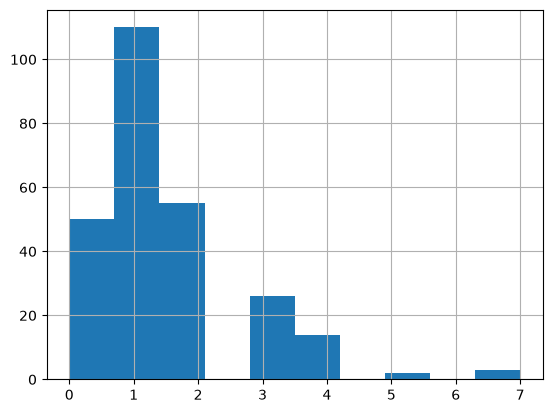

In [18]:
matches_df["home_score"].hist()

<Axes: >

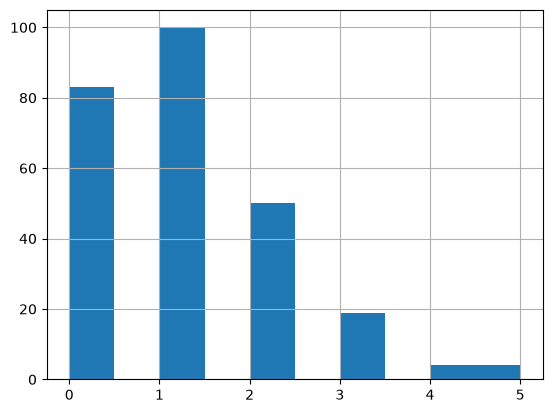

In [19]:
matches_df["away_score"].hist()

# 4. Data Preparation

In [ ]:
# Convert match date to datetime
matches_df["match_date"] = pd.to_datetime(matches_df["match_date"])

# Sort matches chronologically
matches_df = matches_df.sort_values("match_date")

# Check for duplicate records
print(f"Duplicate rows: {matches_df.duplicated().sum()}")

# Check missing values
matches_df.isnull().sum()

matches_df.reset_index(drop=True, inplace=True)

# 5. Feature Engineering

This section creates the variables that will be used by the machine learning model.

At the current stage, only a baseline set of features is implemented. Future versions will incorporate richer football-specific metrics such as recent team form, league standings and home/away performance.

In [1]:
# -----------------------------------
# Baseline Feature Engineering
# -----------------------------------
#
# This first version of the model uses a very limited
# feature set to establish a baseline performance.
#
# Future iterations will incorporate richer football
# metrics such as:
# - Recent team form
# - League standings
# - Home/Away performance
# - Expected Goals (xG)
# - Elo ratings


In [ ]:
# Baseline feature
matches_df["baseline_goal_difference"] = (
    matches_df["home_score"] - matches_df["away_score"]
)

# Define target variable: 1 for home win, 0 for draw, -1 for away win
def determine_result(row):

    if row["home_score"] > row["away_score"]:
        return 1

    elif row["home_score"] == row["away_score"]:
        return 0

    else:
        return -1

matches_df["result"] = matches_df.apply(determine_result, axis=1)

matches_df["result"].value_counts(normalize=True)

Important note

The current baseline model intentionally uses baseline_goal_difference, which is calculated from the final match score. This introduces data leakage and would not be available before kick-off. It is only used to establish an initial reference performance before replacing it with realistic pre-match features in future iterations.

In [9]:
matches_df["result"].value_counts()

result
 1    117
 0     73
-1     70
Name: count, dtype: int64

# 6. Model Training

In [ ]:
# Select features and target
features = ['baseline_goal_difference']  # Extend with more features like team form, injuries, standings position, etc.
X = matches_df[features]
y = matches_df['result']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

# 7. Model Evaluation

In [ ]:
# Make predictions and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Random Forest Accuracy: {accuracy:.2%}")

# Example function to predict a match
def predict_match(home_team, away_team, model):
    # Example feature extraction based on input teams
    # Include logic to fetch current form, injuries, and standings for teams
    # For simplicity, here’s a placeholder example:
    match_features = [[0]]  # Replace with actual features based on the teams
    result = model.predict(match_features)
    return "Home Win" if result == 1 else "Draw" if result == 0 else "Away Win"

# Predict an example match
print(predict_match("Rayo Vallecano de Madrid", "Real Madrid", model))


Model Accuracy: 1.00
Draw


c:\Users\marina.perez\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# 8. Conclusions

The initial baseline demonstrates the end-to-end workflow from data acquisition to model training.

However, the predictive performance is currently limited because only a very small set of features is used.

Future work will focus on engineering richer football-related variables before comparing multiple machine learning models.

# 9. Future Improvements

This baseline model will be extended by incorporating additional football-related features such as:

- Recent team form
- League standings
- Home/Away performance
- Injuries
- Expected Goals (xG)
- Elo ratings
- Hyperparameter tuning